In [3]:
import pandas as pd

# Read the data and get initial campaign info
df = pd.read_csv(rf"C:\Users\haika\Desktop\May_Research\MAC Machine Learning Model Code\MAC_DATASET_LLOD_FILTERED_10campaigns.csv")

In [ ]:
cols_to_avg = ['N1', 'N2', 'N3', 'N_total', 'V1', 'V2', 'V3', 'V_total', 'SAE', 'AAE', 'SSA_red', 'SSA_blue', 'SSA_green', 'b_scat_red', 'b_scat_blue', 'b_scat_green', 'b_abs_red', 'b_abs_blue', 'b_abs_green', 'MAC_bc']
name_to_avg_by = "Campaign"

# Group by campaign and calculate mean for specified columns
df_averaged = df.groupby(name_to_avg_by)[cols_to_avg].mean().reset_index()

print("CAMPAIGN AVERAGES BREAKDOWN")
print("="*50)
print(f"Original dataset: {df.shape[0]} rows")
print(f"Averaged dataset: {df_averaged.shape[0]} campaigns")
print()

# Display the averaged data in a nicely formatted table
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("AVERAGED VALUES BY CAMPAIGN:")
print(df_averaged)

# Optional: Show count of original data points per campaign
print("\nORIGINAL DATA POINTS PER CAMPAIGN:")
campaign_counts = df[name_to_avg_by].value_counts().sort_index()
print(campaign_counts)

# Optional: Show summary statistics
print(f"\nSUMMARY:")
print(f"Total campaigns: {len(df_averaged)}")
print(f"Columns averaged: {len(cols_to_avg)}")

# Save to CSV
df_averaged.to_csv(rf"C:\Users\haika\Desktop\May_Research\MAC Machine Learning Model Code\MAC_DATASET_AVERAGED_BY_CAMPAIGN.csv", index=False)
print(f"\nAveraged data saved to: MAC_DATASET_AVERAGED_BY_CAMPAIGN.csv")

CAMPAIGN AVERAGES BREAKDOWN
Original dataset: 193010 rows
Averaged dataset: 10 campaigns

AVERAGED VALUES BY CAMPAIGN:
                Campaign         N1         N2       N3    N_total  \
0                  ACMEV    23.6119     2.0624   0.0358    26.9920   
1                ASIA-AQ  3627.7941   783.8178  13.0428  4770.2152   
2                   BBOP   197.4249    26.0626   0.4154   242.6883   
3                  CACTI    40.2243     0.9340   0.0172    42.4450   
4                  CARES   171.9942     3.7572   0.1701   178.6987   
5                    DC3   963.6452   603.3265  50.8271  1903.2046   
6  DISCOVERAQ-California  1988.3669  1722.3224 275.7136  4684.7685   
7       DISCOVERAQ-Texas  1908.8378   324.5982 589.7418  3153.4534   
8                FIREXAQ 28780.0338 13801.6560  44.0285 48825.8600   
9               TCAP2013    62.9520     5.8885   0.1037    73.9038   

                 V1                V2               V3           V_total  \
0     57429403.8361     46344919.1

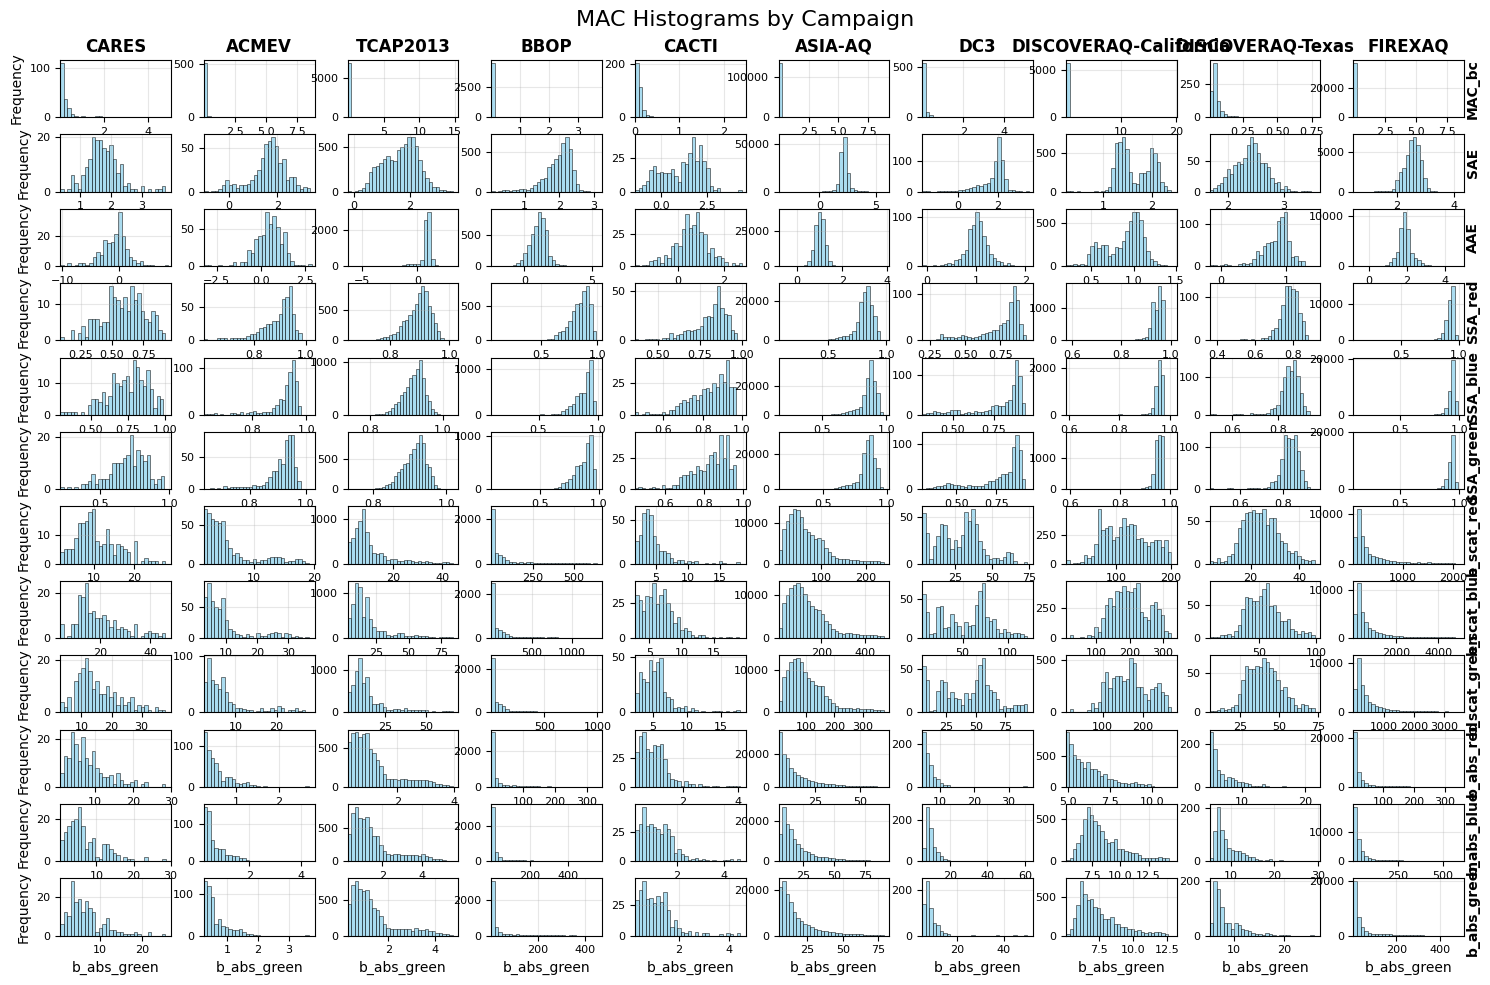

All histograms saved to: campaign_histograms.pdf


<Figure size 640x480 with 0 Axes>

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Your data configuration
cols_to_graph = ['MAC_bc', 'SAE', 'AAE', 'SSA_red', 'SSA_blue', 'SSA_green', 'b_scat_red', 'b_scat_blue', 'b_scat_green', 'b_abs_red', 'b_abs_blue', 'b_abs_green']
name_to_avg_by = "Campaign"

def create_campaign_histograms(df, cols_to_graph, campaign_col, figsize=(15, 10)):
    """
    Create frequency histograms by campaign for specified columns
    
    Parameters:
    df: DataFrame containing the data
    cols_to_graph: List of column names to create histograms for
    campaign_col: Name of the column containing campaign categories
    figsize: Figure size tuple (width, height)
    """
    
    # Get unique campaigns
    campaigns = df[campaign_col].unique()
    n_campaigns = len(campaigns)
    n_cols = len(cols_to_graph)
    
    # Create subplots
    fig, axes = plt.subplots(n_cols, n_campaigns, figsize=figsize, sharey=False, sharex=False)
    
    # Handle case where there's only one row or column
    if n_cols == 1:
        axes = axes.reshape(1, -1)
    if n_campaigns == 1:
        axes = axes.reshape(-1, 1)
    
    # Set overall title
    fig.suptitle(f'{cols_to_graph[0].split("_")[0]} Histograms by Campaign', fontsize=16, y=0.98)
    
    # Create histograms
    for col_idx, col_name in enumerate(cols_to_graph):
        for camp_idx, campaign in enumerate(campaigns):
            ax = axes[col_idx, camp_idx]
            
            # Filter data for this campaign
            campaign_data = df[df[campaign_col] == campaign][col_name].dropna()
            
            # Create histogram
            ax.hist(campaign_data, bins=30, color='skyblue', alpha=0.7, edgecolor='black', linewidth=0.5)
            
            # Set titles and labels
            if col_idx == 0:  # Top row
                ax.set_title(campaign, fontsize=12, fontweight='bold')
            
            if camp_idx == 0:  # Left column
                ax.set_ylabel('Frequency', fontsize=10)
            
            if col_idx == n_cols - 1:  # Bottom row
                if col_name.endswith('_bc'):
                    ax.set_xlabel(f'{col_name} [m²/g]', fontsize=10)
                else:
                    ax.set_xlabel(col_name, fontsize=10)
            
            # Add column name as text on the plot
            if camp_idx == n_campaigns - 1:  # Right column
                ax.text(1.02, 0.5, col_name, rotation=90, va='center', 
                       transform=ax.transAxes, fontsize=10, fontweight='bold')
            
            # Format axes
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', which='major', labelsize=8)
            
            # Set reasonable axis limits using all data
            if len(campaign_data) > 0:
                ax.set_xlim(campaign_data.min(), campaign_data.max() * 1.05)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, hspace=0.3, wspace=0.3)
    
    return fig, axes

# Alternative version with individual subplot titles
def create_campaign_histograms_v2(df, cols_to_graph, campaign_col, figsize=(15, 10)):
    """
    Alternative version with subplot titles showing variable names
    """
    campaigns = df[campaign_col].unique()
    n_campaigns = len(campaigns)
    n_cols = len(cols_to_graph)
    
    fig, axes = plt.subplots(n_cols, n_campaigns, figsize=figsize)
    
    # Handle single row/column cases
    if n_cols == 1:
        axes = axes.reshape(1, -1)
    if n_campaigns == 1:
        axes = axes.reshape(-1, 1)
    
    for col_idx, col_name in enumerate(cols_to_graph):
        for camp_idx, campaign in enumerate(campaigns):
            ax = axes[col_idx, camp_idx]
            
            # Filter data
            campaign_data = df[df[campaign_col] == campaign][col_name].dropna()
            
            # Create histogram
            ax.hist(campaign_data, bins=25, color='lightblue', alpha=0.8, 
                   edgecolor='navy', linewidth=0.5)
            
            # Set title for each subplot
            ax.set_title(f'{campaign}\n{col_name}', fontsize=10)
            
            # Labels
            ax.set_ylabel('Frequency', fontsize=9)
            if col_name.endswith('_bc'):
                ax.set_xlabel(f'{col_name} [m²/g]', fontsize=9)
            else:
                ax.set_xlabel(col_name, fontsize=9)
            
            # Styling
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', labelsize=8)
            
            # Add sample size annotation
            ax.text(0.02, 0.98, f'n={len(campaign_data)}', 
                   transform=ax.transAxes, va='top', ha='left', 
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
                   fontsize=8)
    
    plt.tight_layout()
    return fig, axes

def save_histograms_to_pdf(df, cols_to_graph, campaign_col, pdf_filename='campaign_histograms.pdf', figsize=(15, 10)):
    """
    Save all histogram plots to a single PDF file
    
    Parameters:
    df: DataFrame containing the data
    cols_to_graph: List of column names to create histograms for
    campaign_col: Name of the column containing campaign categories
    pdf_filename: Name of the output PDF file
    figsize: Figure size tuple (width, height)
    """
    from matplotlib.backends.backend_pdf import PdfPages
    import matplotlib.pyplot as plt
    
    with PdfPages(pdf_filename) as pdf:
        # Create and save the main histogram plot
        fig, axes = create_campaign_histograms(df, cols_to_graph, campaign_col, figsize)
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)
        
        # Optionally, create individual pages for each variable
        campaigns = df[campaign_col].unique()
        
        for col_name in cols_to_graph:
            fig, axes = plt.subplots(1, len(campaigns), figsize=(4*len(campaigns), 6))
            
            # Handle case where there's only one campaign
            if len(campaigns) == 1:
                axes = [axes]
            
            fig.suptitle(f'{col_name} by Campaign', fontsize=16)
            
            for camp_idx, campaign in enumerate(campaigns):
                ax = axes[camp_idx]
                
                # Filter data for this campaign
                campaign_data = df[df[campaign_col] == campaign][col_name].dropna()
                
                # Create histogram
                ax.hist(campaign_data, bins=30, color='skyblue', alpha=0.7, 
                       edgecolor='black', linewidth=0.5)
                
                # Set titles and labels
                ax.set_title(campaign, fontsize=12, fontweight='bold')
                ax.set_ylabel('Frequency', fontsize=10)
                
                if col_name.endswith('_bc'):
                    ax.set_xlabel(f'{col_name} [m²/g]', fontsize=10)
                else:
                    ax.set_xlabel(col_name, fontsize=10)
                
                # Format axes
                ax.grid(True, alpha=0.3)
                ax.tick_params(axis='both', which='major', labelsize=8)
                
                # Add sample size annotation
                ax.text(0.02, 0.98, f'n={len(campaign_data)}', 
                       transform=ax.transAxes, va='top', ha='left', 
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
                       fontsize=8)
                
                # Set axis limits
                if len(campaign_data) > 0:
                    ax.set_xlim(campaign_data.min(), campaign_data.max() * 1.05)
            
            plt.tight_layout()
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)
    
    print(f"All histograms saved to: {pdf_filename}")

# Usage to save to PDF:
# save_histograms_to_pdf(df, cols_to_graph, name_to_avg_by, 'my_histograms.pdf')

def save_single_page_pdf(df, cols_to_graph, campaign_col, pdf_filename='campaign_histograms_single.pdf', figsize=(15, 10)):
    """
    Save just the main combined histogram plot to PDF (single page)
    """
    from matplotlib.backends.backend_pdf import PdfPages
    import matplotlib.pyplot as plt
    
    with PdfPages(pdf_filename) as pdf:
        fig, axes = create_campaign_histograms(df, cols_to_graph, campaign_col, figsize)
        pdf.savefig(fig, bbox_inches='tight', dpi=300)
        plt.close(fig)
    
    print(f"Single-page histogram saved to: {pdf_filename}")

# Usage for single page PDF:
# save_single_page_pdf(df, cols_to_graph, name_to_avg_by, 'single_page_histograms.pdf')

# Usage example:
# Assuming your dataframe is called 'df'
fig, axes = create_campaign_histograms(df, cols_to_graph, name_to_avg_by)
plt.show()

# Save all histograms to multi-page PDF
save_histograms_to_pdf(df, cols_to_graph, name_to_avg_by, 'campaign_histograms.pdf')

# Or save the figure as PNG
plt.savefig('campaign_histograms.png', dpi=300, bbox_inches='tight')

# For the alternative version:
# fig, axes = create_campaign_histograms_v2(df, cols_to_graph, name_to_avg_by)
# plt.show()
